# Customer Attrition in the Banking Sector : Understanding the Key Drivers and Mitigation Strategies

# I. Introduction

Customer attrition, commonly referred to as customer churn in most industries/business cases, is a significant challenge the banking sector faces today. Despite efforts to attract and retain customers through various loyalty programs, personalized services, and technological innovations, banks continue to experience high rates of customer turnover. This attrition leads to considerable financial losses and erodes customer satisfaction and trust, critical components of a bank's long-term success. Understanding the key drivers behind customer attrition is essential for developing effective mitigation strategies to enhance customer loyalty and reduce churn rates. This study leverages machine learning tools to explore the primary factors contributing to customer attrition in the banking sector and explores strategic approaches to address this persistent issue. By identifying and addressing the root causes of churn and utilising data tools, banks can improve customer retention efforts, ensuring sustained growth and stability in an increasingly competitive marketplace. 

# II. Data Gathering + Exploratory Analysis

As a disclaimer, this project uses notional banking data. While this project analysis cannot be actioned in the real world, it aims to develop a framework and act as a proof of concept to be optimized and redeveloped for future purposes. Finding relevant data to analyze customer churn in the banking sector poses a significant challenge because banks are reluctant to release public data due to data privacy rules. This lack of transparency in the banking industry makes it difficult for researchers and analysts to access comprehensive datasets that can provide insights into customer behaviour and the factors influencing their decision to leave. 

To overcome this challenge, I have opted to use a Kaggle dataset downloaded from superdatascience.com in a deep learning module, which is cited within this documentation. This notional dataset contains customer information for a hypothetical bank and will serve as a placeholder for our future use cases and churn-related models. 

In [1]:
import pandas as pd
import plotly.express as px

In [2]:
churn_data = pd.read_csv("/kaggle/input/banking-churn-modelling/Churn_Modelling.csv")
churn_data

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [3]:
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


## Attribute Names + Definitions 
- RowNumber: A unique ID for each record, not directly used in the analysis.
- CustomerId: Identifies and differentiates individual customers in the dataset.
- Surname: Shows the last name of each customer.
- CreditScore: A numerical score evaluating a customer's creditworthiness.
- Geography: Indicates the customer's location, useful for regional analysis.
- Gender: Classifies customers as male or female for potential gender-based analysis.
- Age: Represents the customer's age in years, useful for identifying age-related trends.
- Tenure: Shows how long the customer has been with the bank.
- Balance: Displays the amount of money in the customer's bank account.
- NumOfProducts: Indicates the number of products the customer uses, like loans or credit cards.
- HasCrCard: A binary value showing if the customer has a credit card (1 = yes, 0 = no).
- IsActiveMember: A binary value indicating if the customer is active (1) or inactive (0).
- EstimatedSalary: An approximation of the customer's income level.
- Exited: A binary indicator showing if the customer has left the bank (1 = yes, 0 = no), which we aim to predict.

In [4]:
from ydata_profiling import ProfileReport
churn_data_profile = ProfileReport(churn_data, title='Churn_Data_Profile')
churn_data_profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## Data Profile Inferences
Based on the data profile report, The dataset contains 14 variables and 10,000 observations. There are no missing values, which means there is no need to drop null value cells (as they do not exist), and there are no duplicate values as indicated by the attribute customer_id being 100% distinct. 

The next step is to drop columns that are not required for the analysis. I have chosen to remove the attributes "RowNumber" & "Surname".  The "RowNumber" attribute acts as a unique ID and ensures there are no duplicate records, this is not required since we know we have 100% unique values shown to us by the profile report. Opting to remove the "Surname" attribute, as this term is unnecessary in our analysis. I have also chosen to keep the "CustomerId" column as this will be useful for identifying potential outliers, and for prompting further investigation.

In [5]:
churn_data.drop(columns=["RowNumber","Surname"],inplace=True)
churn_data.head()

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# III. IDENTIFYING SCOPE AND BUSINESS ANALYSIS

Now that the data is prepared, I need to assess the scope of customer churn. How many of the 10,000 customers have left? , and what percentage does that represent? Along with this I want to understand how each different term has an impact on the customer's likelihood to exit. To do this, I will analyse and attempt to spot any underlying trends by overlaying the each attribute and filtering by "Exited". 

To begin, I will visualize the "Exited" attribute to understand the scope of the churn.

In [6]:
#Starting with counting the number of churned within the bank
exited_count = churn_data["Exited"].value_counts().reset_index()

# Rename the columns for clarity
exited_count.columns = ['Exited', 'Count']

# Mapping 0 and 1 to 'No' and 'Yes'
exited_count['Exited'] = exited_count['Exited'].map({1: 'Yes', 0: 'No'})

# Create the pie chart using Plotly
exit_pie = px.pie(exited_count, names='Exited', values='Count', 
                   title='Customer Exit Count')
# Display the pie chart
exit_pie.show()

The proportion of customers who exited (in red) versus those who remained with the bank (in blue). Approximately 79.6% of customers have stayed with the bank, while 20.4% of customers have exited. This indicates that the majority of the customer base remains loyal, though a significant portion (around one-fifth) has left. The target is to identify the cause of this based on the data available and develop a strategy to reduce this number. 

Continuing with the analysis of the data, I will now examine the proportion of customers labeled as "isActiveMember", this is because it is natural to assume a customer is more likely to exit if they are not making use of the services, and this will need to be tested. Additionally, we need to clarify the definition of "inactive member" for this bank and understand how this definition influences the concept of "Exited".  

In [7]:
active_count = churn_data["IsActiveMember"].value_counts().reset_index()
active_count.columns = ['active', 'Count']
# Renaming 0 and 1 to Yes and No
active_count['active'] = active_count['active'].map({1: 'Yes', 0: 'No'})

# Create the pie chart using Plotly
active_pie = px.pie(active_count, names='active', values='Count', 
                   title='Active Member Count')

# Display the pie chart
active_pie.show()

#showing active and inactive customers who have exited 
active_exit_count = churn_data.groupby(['IsActiveMember', 'Exited']).size().reset_index(name='Count')

# Map 1 to 'Yes' and 0 to 'No' for readability
active_exit_count['IsActiveMember'] = active_exit_count['IsActiveMember'].map({1: 'Active', 0: 'Inactive'})
active_exit_count['Exited'] = active_exit_count['Exited'].map({1: 'Yes', 0: 'No'})

# Create the bar chart using Plotly Express
fig = px.bar(active_exit_count, x='Exited', y='Count', color='IsActiveMember', 
             title='Count of Active vs Inactive Members by Exited Status',
             labels={'Exited', 'Count', 'Number of Customers', 'IsActiveMember', 'Customer Status'},
             color_discrete_map={'Active': 'blue', 'Inactive': 'red'})

# Display the bar chart
fig.show()


The active member count pie chart shows that 51.5% of the customers are marked as active, while 48.5% are inactive. This near-even split doubles on the previous questions about the bank's definition of "active." What activities qualify a customer as active, and how do inactive customers contribute to overall churn? Inactive in retail banking is defined as "When an account becomes inactive, it means that the account holder has not made any deposits, withdrawals, or other transactions within the specified time frame." (PAYTM Blog). This coincides with how it is defined in my own experience working in a bank so we will stick with this definition. 

The inference that can be made with that definition is that this data acts as a snapshot in time, explaining why there could be a larger number of inactive customers than initially expected. However, without access to historical records, it is not possible to determine the duration of inactivity required for a customer to be classified as dormant or "inactive." This limitation poses a challenge for the analysis, as a more comprehensive database that tracks customer activity over time would yield more accurate and insightful results.

Given that this is a proof of concept, this snapshot of the "isActiveMember" and the "Tenure" attributes will suffice for now. This is because "Tenure" gives us the duration of time a customer has been with the bank, which is something that will be explored and raises the question of how much impact "Tenure has on exited". In future iterations, conducting a time-series analysis of customer activity over an extended period will be crucial for further development and fine-tuning of the model.

Looking at the second figure produced, two observations can be seen that when overlaying the activity status on top of the inactivity status. 
- Firstly, among the number of customers who have exited, the proportion of inactive customers is higher than active customers. This backs up the initial theory that customers are more likely to churn if they are not using the service (in any case, not just banking), the same applies to the converse. 
- Secondly, of the number of customers who have exited, 36% are marked as active users. This is a key point to investigate, is there an underlying trend within this specific group? 


SOURCE:
https://paytm.com/blog/savings-account/inactive-savings-account-vs-dormant-savings-account/#:~:text=When%20an%20account%20becomes%20inactive,any%20significant%20activity%20or%20transactions. 

The next step is to look at geography, is the bank more dominant in one particular geography than others? Does this have an impact on the number of customers exiting?

In [8]:
# country by customers filtered
country_customer_count = churn_data.groupby('Geography').size().reset_index(name='Count')
customers_by_country = px.pie(country_customer_count, values='Count', names='Geography', 
             title='Customer Count Per Country',
             color_discrete_map={'France': 'blue', 'Germany': 'green', 'Spain': 'red'})

# Show the pie chart
customers_by_country.show()

This pie chart shows the distribution of customer counts per country, with France holding the largest portion at 50.1%, Germany with 25.1% and Spain with 24.8%. From this, we infer that France is the dominant market for the bank, representing half of the total customer base. Based on this, we can assume that the bank may prioritize its resources and services toward retaining and expanding its customer base in France, while still maintaining a substantial presence in Germany and Spain. It would be fair to assume that there would be a higher likelihood of customer churn in France compared to the other two geographies as the sample size is larger. I will test this theory by aggregating and visualizing the number of customers who exited in each geography.

In [9]:
import plotly.express as px
# Create an interactive bar chart using Plotly
# Group the data and create a new DataFrame for plotting
country_exit_counts = churn_data.groupby(['Geography', 'Exited']).size().reset_index(name='Count')

# Map the Exited column from 0/1 to No/Yes
country_exit_counts['Exited'] = country_exit_counts['Exited'].map({1: 'Yes', 0: 'No'})

# Create an interactive bar chart using Plotly
exits_by_country = px.bar(country_exit_counts, x='Exited', y='Count', color='Geography', barmode='group',
                          labels={'Exited': 'Exited', 'Count': 'Number of Customers'},
                          title="Exited by Country",
                          height=600, width=800,
                          color_discrete_map={'France': 'blue', 'Germany': 'green', 'Spain': 'red'})

# Show the interactive plot
exits_by_country.show()

The first observation that can be seen is that France has the highest number of non-exited customers, followed by Germany and Spain, while the number of exited customers is relatively smaller across all three countries. This suggests that the bank experiences stronger retention in France, but there is a more balanced churn situation in Germany and Spain, indicating potential opportunities for improvement in customer retention in these regions. 

Next, I want to look at whether number of products a customer holds has an impact on a customer exiting. The notion is that a customer with a higher number of products is less likely to exit the bank, as it would require terminating multiple parts of their account, it can also be seen as an indicator of customer loyalty to the bank. 

## Customer Churn on Number of Products

In [10]:
# Grouping data by number of products and exited status
product_exit_count = churn_data.groupby(['NumOfProducts', 'Exited']).size().reset_index(name='Count')

# Map the Exited column from 0/1 to No/Yes for clarity
product_exit_count['Exited'] = product_exit_count['Exited'].map({1: 'Yes', 0: 'No'})

# Create the stacked bar chart
fig = px.bar(product_exit_count, x='NumOfProducts', y='Count', color='Exited', 
             title='Number of Products vs Customer Exit Status',
             labels={'NumOfProducts': 'Number of Products', 'Count': 'Number of Customers'},
             height=600, width=800,
             barmode='stack')

fig.update_xaxes(tickmode='linear', tick0=1, dtick=1)
fig.update_yaxes(tickmode='linear', tick0=0, dtick=500)

# Display the chart
fig.show()

From the 'Number of Products vs Customer Exit Status', it appears that the customers with 2 products are the least likely to exit. This contradicts my earlier hypothesis that more products would equate to unlikely churn. All of the customers with 4 products had exited the bank, and 83% of the customers with 3 products had exited. However, there are very few customers with more than 2 products. 

Next looking to see if there are any clear trends on customer exits by gender.

## Customer Churn based on Gender

In [11]:
gender_exit_count = churn_data.groupby(['Gender', 'Exited']).size().reset_index(name='Count')

# Map the Exited column from 0/1 to No/Yes for clarity
gender_exit_count['Exited'] = gender_exit_count['Exited'].map({1: 'Yes', 0: 'No'})

# Create a bar chart to visualize churn by gender
fig = px.bar(gender_exit_count, x='Gender', y='Count', color='Exited', 
             title='Churn by Gender',
             labels={'Exited': 'Exited (Yes or No)', 'Count': 'Number of Customers'},
             barmode='group',
             height=600, width=800)

# Show the interactive plot
fig.show()

This indicates that while there are more male customers overall, a higher proportion of female customers have exited than their male counterparts. Specifically, females show a larger percentage of churn than their total population, suggesting they may be more susceptible to leaving the bank. Although males represent a larger customer base, their churn rate is comparatively lower. This disparity highlights potential differences in customer experience or satisfaction between genders, which may require targeted retention strategies to better address the needs of female customers and reduce their likelihood of exiting. Next I will determine if there is a trend on the various age groups and their effect on customer churn. 

## Customer Churn based on Age

In [12]:
# Grouping the data by Age and Exited status to create a count of customers for each age group and exit status
age_exit_count = churn_data.groupby(['Age', 'Exited']).size().reset_index(name='Count')
age_exit_count['Exited'] = age_exit_count['Exited'].map({1: 'Yes', 0: 'No'})

# Create a bar chart to visualize churn by age as a continuous variable
fig = px.bar(age_exit_count, x='Age', y='Count', color='Exited', 
             title='Churn by Age',
             labels={'Exited': 'Exited (Yes or No)', 'Count': 'Number of Customers'},
             height=600, width=800)

# Show the interactive plot
fig.show()

This highlights a clear relationship between customer age and churn. The highest churn rates are observed among middle-aged customers, particularly between the ages of 40 and 50, indicating that this group is more prone to leaving the bank. A significant portion of the bank's customer base falls within the 30 to 50-year-old range, making this demographic critical for retention efforts. In contrast, churn rates decline notably for customers over 60, suggesting greater loyalty or stability among older customers. Similarly, younger customers under 30 exhibit lower churn rates, implying they may still be in the early stages of their relationship with the bank and are less likely to leave. This suggests that middle-aged customers seemingly warrant the most attention in terms of churn prevention strategies, while older and younger customers appear to be more stable in their banking relationships.

Now I want to see if there is any trend with the Tenure, the time a customer has spent with the bank, and churn. 

## Customer Churn based on Tenure

In [13]:

# Grouping the data by Tenure and Exited status to create a count of customers for each tenure group and exit status
tenure_exit_count = churn_data.groupby(['Tenure', 'Exited']).size().reset_index(name='Count')

tenure_exit_count['Exited'] = tenure_exit_count['Exited'].map({1: 'Yes', 0: 'No'})

# Create a bar chart to visualize churn by tenure as a continuous variable
fig = px.bar(tenure_exit_count, x='Tenure', y='Count', color='Exited', 
             title='Churn by Tenure',
             labels={'Exited': 'Exited (Yes or No)', 'Count': 'Number of Customers'},
             height=600, width=800)

# Show the interactive plot
fig.show()

Looking at Churn based on tenure the barchart shows that churn rates vary across different tenures. Customers with zero years of tenure exhibit the highest churn rate, indicating that those who join and exit within the first year are particularly vulnerable to leaving, likely due to dissatisfaction early in their relationship with the bank. In contrast, customers with ten years of tenure show a relatively low churn rate, suggesting that longer-term customers are more loyal and less likely to exit. Between 1 and 9 years of tenure, churn remains relatively stable, with no significant reduction over time, implying that simply staying with the bank for a few years does not guarantee customer retention. Overall, the extremes of tenure—particularly new customers and long-standing customers—show more distinct churn patterns compared to the middle ranges.

Finally, we will look at the trend of credit score on customers exiting. 

## Customer Churn based on Credit Score

In [14]:

churn_data['Exited'] = churn_data['Exited'].map({1: 'Yes', 0: 'No'})

# Create a box plot to visualize the distribution of credit scores for churned and non-churned customers
fig = px.box(churn_data, x='Exited', y='CreditScore', color='Exited', 
             title='Credit Score Distribution by Churn Status',
             labels={'Exited': 'Exited (Yes or No)', 'CreditScore': 'Credit Score'},
             notched=True)  # Add notches to highlight the confidence interval around the median

# Show the plot
fig.show()

The boxplots illustrate the distribution of credit scores for customers who churned and those who did not. For customers who churned, the median credit score is 646, with an interquartile range from 578 to 716. The whiskers extend from a minimum score of 350 to a maximum of 850. Comparatively, the non-churned group has a slightly higher median credit score of 653, with an interquartile range from 585 to 718, and a score range between 405 and 850. Both groups show similar distributions, with significant overlap in their credit scores across quartiles and ranges.

These observations suggest that while non-churned customers tend to have slightly higher credit scores on average, the difference is not substantial. The overlap in the distributions implies that credit score alone is not a strong predictor of churn. Both churned and non-churned customers span a wide range of credit scores, indicating that other factors, such as customer experience, engagement, or product use, likely play a more critical role in determining whether a customer stays or leaves. Therefore, credit score should be considered in conjunction with other variables when predicting churn.

## Correlation Matrix of Variables on Exit

Having analyzed individual factors, such as age, tenure, and credit score, to understand how they relate to customer churn. While these visualizations offer valuable insights, they do not provide a holistic view of the relationships between multiple variables and churn. To gain a deeper understanding of how these factors are interconnected and to quantify their influence on churn, the best way to visualize this would be to use a correlation matrix. This will allow us to assess the strength and direction of linear relationships between our variables and churn more comprehensively.

In [15]:
import pandas as pd
import plotly.express as px
import plotly.figure_factory as ff

# Selecting numerical columns for correlation (excluding ID in this case)
numerical_columns = churn_data.select_dtypes(include=['float64', 'int64']).columns
numerical_columns = numerical_columns.drop('CustomerId')

# Computing the correlation matrix
correlation_matrix = churn_data[numerical_columns].corr()

# Create a correlation matrix heatmap using Plotly
fig = ff.create_annotated_heatmap(
    z=correlation_matrix.values,
    x=list(correlation_matrix.columns),
    y=list(correlation_matrix.index),
    annotation_text=correlation_matrix.round(2).values,
    colorscale='Viridis',
    showscale=True
)

# Update layout for better appearance
fig.update_layout(title="Correlation Matrix of Features Leading to Customer Exit",
                  xaxis_title="Features",
                  yaxis_title="Features")


fig.update_layout(
    title="Correlation Matrix of Features Leading to Customer Exit",
    xaxis_title="Features",
    yaxis_title="Features",
    width=1000,  # Set the width of the figure
    height=800   # Set the height of the figure
)
# Display the correlation matrix
fig.show()

The correlation analysis reveals that age and balance are the most significant predictors of customer churn. Older customers and those with higher balances exhibit a stronger tendency to exit, implying that dissatisfaction may arise despite their financial position. In contrast, financial indicators such as credit score and estimated salary have little to no influence on customer churn, suggesting that these metrics are not as critical in determining loyalty. Furthermore, the weak negative correlation between active membership and churn indicates that while active engagement helps reduce exits, it is not a decisive factor on its own.

While this provides valuable insights into the linear relationships between features and churn, it only scratches the surface of customer behaviour. By leveraging classification algorithms such as logistic regression. To capture more complex, non-linear patterns and interactions among features, machine learning models can be employadient boosting, the bank can build predictive models to better identify at-risk customers and proactively engage them before they churn. Machine learning offers a more nuanced approach, allowing for more accurate and actionable predictions that go beyond simple correlations.

# IV. LOGISTIC REGRESSION

The logistic regression formula for predicting the probability of churn ($P(\text{churn})$) can be expressed as:

$$
P(\text{churn}) = \frac{1}{1 + e^{-z}}
$$

Where $z$ is the linear combination of the input features, represented as:

$$
z = \beta_0 + \beta_1 \cdot \text{CreditScore} + \beta_2 \cdot \text{Age} + \beta_3 \cdot \text{Tenure} + \beta_4 \cdot \text{Balance} + \beta_5 \cdot \text{NumOfProducts} + \beta_6 \cdot \text{IsActiveMember}
$$

### Explanation of the Terms:
- $\beta_0$: Intercept (bias term), which adjusts the baseline prediction independent of the input features.
- $\beta_1, \beta_2, \dots, \beta_6$: Coefficients (weights) for each respective feature in the model. These values are learned during model training and represent the impact of each feature on the likelihood of churn.
- $\text{CreditScore}$, $\text{Age}$, $\text{Tenure}$, $\text{Balance}$, $\text{NumOfProducts}$, $\text{IsActiveMember}$: These are the input features that influence the outcome (customer churn). They are multiplied by their respective weights in the model to contribute to the prediction.

### Logistic Regression Probability Calculation:

Once $z$ is calculated, we apply the **logistic function (sigmoid function)** to transform $z$ into a probability. The probability that the customer will churn is:

$$
P(\text{churn}) = \frac{1}{1 + e^{-z}}
$$

This formula ensures that the output is between 0 and 1, representing the probability of churn.

### Decision Rule for Classification:

After calculating the probability $P(\text{churn})$, we apply the following decision rule to classify the customer as either churned or not churned:

$$
\hat{y} =
\begin{cases} 
1 & \text{if } P(\text{churn}) \geq 0.5 \\
0 & \text{if } P(\text{churn}) < 0.5 
\end{cases}
$$

Here:
- $\hat{y} = 1$: The customer is predicted to churn (Exited = 1).
- $\hat{y} = 0$: The customer is predicted not to churn (Exited = 0).

### Example Calculation:

Consider the following coefficients obtained from training the logistic regression model:
- $\beta_0 = -1.5$: This is the intercept term.
- $\beta_1 = 0.02$: Coefficient for $\text{CreditScore}$.
- $\beta_2 = 0.04$: Coefficient for $\text{Age}$.
- $\beta_3 = -0.01$: Coefficient for $\text{Tenure}$.
- $\beta_4 = 0.0001$: Coefficient for $\text{Balance}$.
- $\beta_5 = 0.1$: Coefficient for $\text{NumOfProducts}$.
- $\beta_6 = -0.5$: Coefficient for $\text{IsActiveMember}$.

Now, suppose we have a customer with the following feature values:
- $\text{CreditScore} = 600$
- $\text{Age} = 40$
- $\text{Tenure} = 3$
- $\text{Balance} = 50000$
- $\text{NumOfProducts} = 2$
- $\text{IsActiveMember} = 1$

Using these values, we calculate $z$:

$$
z = -1.5 + (0.02 \cdot 600) + (0.04 \cdot 40) + (-0.01 \cdot 3) + (0.0001 \cdot 50000) + (0.1 \cdot 2) + (-0.5 \cdot 1)
$$

Simplifying step by step:

$$
z = -1.5 + 12 + 1.6 - 0.03 + 5 + 0.2 - 0.5 = 16.77
$$

### Probability Calculation:

We then calculate the probability of churn using the logistic function:

$$
P(\text{churn}) = \frac{1}{1 + e^{-16.77}} \approx 0.9999
$$

This means the customer has a very high probability of churning.


The logistic regression model provides the probability of churn based on customer features such as credit score, age, tenure, balance, number of products, and activity status. By predicting churn probabilities, the business can focus on high-risk customers (those with a high predicted probability of churn) for targeted retention strategies, such as offering incentives or personalized communication to reduce churn.

Now I will apply the regression model and divide the data into training and test splits.

Accuracy: 0.80
ROC-AUC Score: 0.67
              precision    recall  f1-score   support

          No       0.81      0.98      0.89      1607
         Yes       0.42      0.07      0.12       393

    accuracy                           0.80      2000
   macro avg       0.61      0.52      0.50      2000
weighted avg       0.73      0.80      0.74      2000



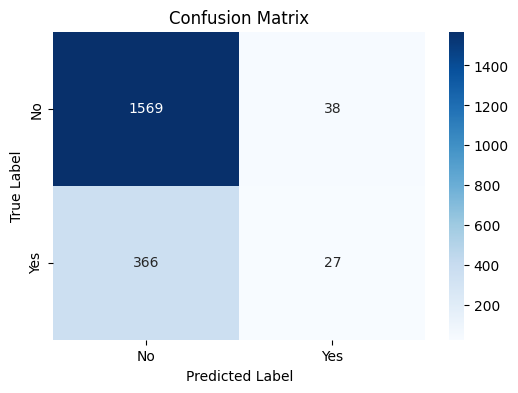

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score,  confusion_matrix

# Select features and target variable
X = churn_data[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'IsActiveMember']]  # Features
y = churn_data['Exited']  # Target (Churn or Not)

# Convert categorical columns to dummy/indicator variables if needed (e.g., Gender, Geography)
X = pd.get_dummies(X, drop_first=True)

# Step 2: Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Step 4: Make predictions on the test set
y_pred = model.predict(X_test)

# Step 5: Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

print(f'Accuracy: {accuracy:.2f}')
print(f'ROC-AUC Score: {roc_auc:.2f}')
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Regression Results and Inference
The logistic regression model achieved an accuracy of 80% on the test data. While this may appear to be a strong result, accuracy alone is not a sufficient measure of performance in cases of class imbalance. In this scenario, the number of churned customers is significantly smaller than those who remained loyal, meaning the model could achieve high accuracy by favoring the majority class (non-churners) without properly identifying the minority class (churners).

The ROC-AUC score of 0.67 suggests that the model is moderately successful at distinguishing between churners and non-churners. The ROC-AUC score ranges from 0.5 (indicating random guessing) to 1.0 (indicating perfect classification). A score of 0.67 shows that the model can rank customers by their likelihood of churn to a reasonable extent, but there remains considerable room for improvement. Alternative models, such as XGBoost, could potentially improve this score by better handling class imbalance and nonlinear relationships between features.

Although the model performs well in identifying non-churners, with a precision of 0.81 and an impressive recall of 0.98, it struggles substantially in identifying actual churners. The precision for churners is just 0.42, and the recall is alarmingly low at 0.07, meaning that the model correctly identifies only 7% of actual churners. This imbalance between non-churners and churners is further reflected in the disparity of the F1-scores: 0.89 for non-churners and only 0.12 for churners. This performance indicates that while the model may be successful at predicting customers who will stay, it fails to effectively capture the churners, leading to missed opportunities for customer retention strategies.

The confusion matrix provides a detailed visualization of this issue. The "No" class (non-churners) shows 1,569 true negatives, meaning the model correctly identified 1,569 customers who did not churn. However, it misclassified 38 non-churners as churners (false positives). In contrast, for the "Yes" class (churners), the model correctly identified only 27 churners (true positives), but failed to identify 366 churners, classifying them instead as non-churners (false negatives). This high number of false negatives clearly demonstrates the model's difficulty in accurately predicting customers who are likely to churn. This weakness aligns with the low recall for churners observed earlier, reinforcing that while the model is proficient at identifying non-churners, it falls short in predicting churners, ultimately reducing its effectiveness in supporting retention interventions.

# V. ADDRESSING CLASS IMBALANCE (SMOTE REGRESSION)

This imbalanced dataset poses a problem for machine learning models because they tend to favor the majority class, leading to poor performance in detecting the minority class. One key performance metric, recall (sensitivity or true positive rate) for churners, is often particularly low in such imbalanced scenarios. To address the problem, I will use Synthetic Minority Over-sampling Technique or SMOTE to balance the class distribution by generating synthetic samples of the minority class. Logistic regression is sensitive to class imbalance as it tries to find a linear relationship between the input features and the probability of churn. SMOTE helps the logistic model discover a more balanced relationship between the features for both churners and non-churners.  By generating more diverse training samples for the minority class, SMOTE ensures that the model is exposed to a wider variety of churner behaviors, which helps in generalizing better to unseen data. Consequently, this helps avoid bias towards the majority class and shifts the optimization focus to both classes equally. Ideally, this should result in a higher recall for churners (minority class).

Now I will apply SMOTE and run the regression again

Accuracy: 0.63
ROC-AUC Score: 0.71
              precision    recall  f1-score   support

          No       0.89      0.61      0.73      1607
         Yes       0.31      0.69      0.42       393

    accuracy                           0.63      2000
   macro avg       0.60      0.65      0.58      2000
weighted avg       0.78      0.63      0.67      2000



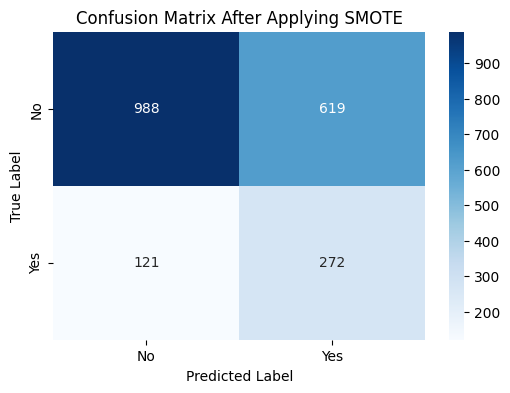

In [17]:
from imblearn.over_sampling import SMOTE

X = churn_data[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'IsActiveMember']]  # Features
y = churn_data['Exited']  # Target (Churn or Not)

# Convert categorical columns to dummy/indicator variables
X = pd.get_dummies(X, drop_first=True)

# Step 1: Split the data into training and test sets before applying SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Step 3: Initialize and train the Logistic Regression model on SMOTE data
model = LogisticRegression(max_iter=1000)
model.fit(X_train_smote, y_train_smote)

# Step 4: Make predictions on the test set
y_pred = model.predict(X_test)

# Step 5: Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

print(f'Accuracy: {accuracy:.2f}')
print(f'ROC-AUC Score: {roc_auc:.2f}')
print(classification_report(y_test, y_pred))

# Step 6: Confusion Matrix to check improvements in recall
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
plt.title("Confusion Matrix After Applying SMOTE")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In contrast to the regression model previously, after applying SMOTE to balance the classes, the model's accuracy dropped to 63%. This was compensated by a substantial improvement in recall for churners, which rose dramatically to 0.69. This indicates that the SMOTE-enhanced model is much more effective at identifying at-risk customers, although at the cost of increasing false positives, as seen in the drop in precision for churners from 0.42 to 0.31. Additionally, the ROC-AUC score improved from 0.67 to 0.71, reflecting the model's enhanced ability to differentiate between churners and non-churners.

The confusion matrix illustrates this trade-off clearly. For non-churners ("No"), the model now correctly classifies 988 customers, but misclassifies 619 non-churners as churners (false positives). For churners ("Yes"), the model successfully identifies 272 churners (true positives) out of 393, while misclassifying 121 churners as non-churners (false negatives). This is a substantial improvement in true positive detection for churners compared to the previous model, which identified only 27 churners. Although SMOTE has increased the model's ability to detect churners, the increase in false positives and the reduction in precision must be managed carefully to avoid unnecessary retention interventions for customers who are not at risk of leaving. 

Given the limitations of logistic regression, even with the application of SMOTE, it becomes evident that while we can improve recall for churners, this comes at the expense of overall accuracy and precision. The trade-offs between detecting churners and avoiding false positives highlight the inherent limitations of simpler linear models like logistic regression when handling complex relationships within imbalanced data. To further enhance model performance, particularly in improving both recall and precision simultaneously, it is worth exploring more sophisticated machine learning algorithms.

# VI. XGBOOST

XGBoost constructs an ensemble of decision trees by minimizing the regularized objective function through gradient descent. In each iteration, it builds trees that correct the errors of previous trees using gradients of the loss function. For customer churn prediction, this process allows XGBoost to model complex, non-linear relationships between features (e.g., CreditScore, Age, Tenure) and churn while being robust to class imbalance through techniques such as adjusting scale_pos_weight and regularization. 

The scale_pos_weight parameter adjusts the weight assigned to positive examples (the minority class) during training. By setting scale_pos_weight, XGBoost can penalize misclassifications of the minority class more heavily, making the model more sensitive to correctly predicting those instances. The value of scale_pos_weight can be set based on the ratio between the majority and minority classes:

scale pos weight =
Number of positive samples /
number of negative samples

This helps the model better handle imbalanced datasets by giving more focus to the minority class.

Implementing this through the xgboost package below 

In [18]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_curve, auc, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming churn_data is already loaded and prepared

# Step 1: Prepare the feature matrix X and the target vector y
X = churn_data[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'IsActiveMember']]
y = churn_data['Exited'].map({'No': 0, 'Yes': 1})  # Convert 'Yes'/'No' to 1/0

# Step 2: Split the data into training and testing sets using stratified sampling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Step 3: Calculate the scale_pos_weight, with checks to prevent ZeroDivisionError
negative_count = len(y_train[y_train == 0])
positive_count = len(y_train[y_train == 1])

# Avoid division by zero
if positive_count > 0:
    scale_pos_weight = negative_count / positive_count
else:
    scale_pos_weight = 1  # Default to 1 if there's no positive class

# Step 4: Initialize and train the XGBoost model with class imbalance handling
xgb_model = xgb.XGBClassifier(use_label_encoder=False, scale_pos_weight=scale_pos_weight, random_state=42)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# Step 5: Make predictions and evaluate the model
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f'Accuracy: {accuracy:.2f}')
print(f'ROC-AUC Score: {roc_auc:.2f}')
print(classification_report(y_test, y_pred))

Accuracy: 0.80
ROC-AUC Score: 0.81
              precision    recall  f1-score   support

           0       0.90      0.84      0.87      1593
           1       0.50      0.62      0.55       407

    accuracy                           0.80      2000
   macro avg       0.70      0.73      0.71      2000
weighted avg       0.82      0.80      0.80      2000



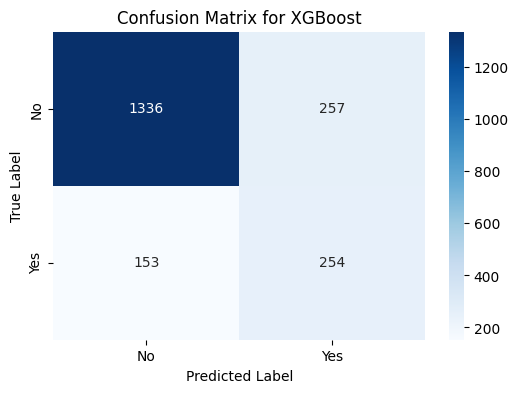

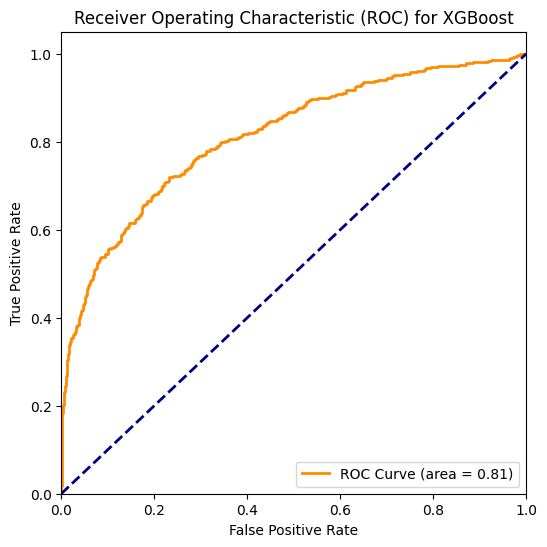

In [19]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
plt.title("Confusion Matrix for XGBoost")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (area = {roc_auc_value:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for XGBoost')
plt.legend(loc="lower right")
plt.show()

The XGBoost model achieved a strong overall accuracy of 80%, which matches the performance of the previous models. More importantly, the model demonstrated a significant improvement in the ROC-AUC score of 0.81, reflecting a better balance between correctly identifying both churners and non-churners. The precision for churners (class 1) was 0.50, and the recall increased to 0.62, indicating that the model successfully identified 62% of actual churners, which is a marked improvement over previous models like logistic regression. However, the trade-off between precision and recall still exists, where the model correctly identified fewer true churners than true non-churners.

The confusion matrix for the XGBoost model shows that the model correctly identified 1,336 non-churners (true negatives) out of 1,593, while misclassifying 257 non-churners as churners (false positives). For churners, the model correctly predicted 254 (true positives) out of 407 but misclassified 153 as non-churners (false negatives). This indicates that the model performs well at predicting non-churners but struggles more with correctly identifying churners, likely due to the inherent class imbalance in the dataset. Although the model achieves good accuracy (80%) overall, its precision and recall for churners are lower, indicating that it misses a notable proportion of actual churners and sometimes misclassifies non-churners as churners.

The area under the curve (AUC) is 0.82, which indicates that the model performs well above random chance (AUC of 0.5). The ROC curve is relatively steep, showing that the model achieves a good trade-off between correctly identifying churners and minimizing false positives. This solid AUC score, combined with improved recall and balanced precision, indicates that XGBoost is well-suited for identifying customers at risk of churn while maintaining a reasonable level of false alarms, making it a robust solution for churn prediction in this case.

# VII. FEATURE IMPORTANCE

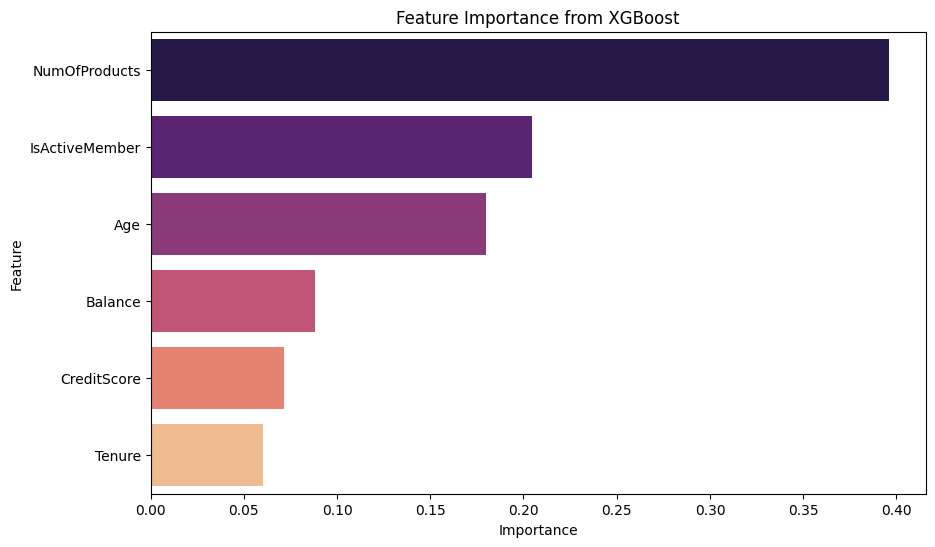

In [20]:
# XGBOOST FEATURE IMPORTANCE
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': xgb_model.feature_importances_})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')
plt.title('Feature Importance from XGBoost')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

The feature importance plot generated from the XGBoost model provides insight into which features had the most significant impact on predicting customer churn. In this plot, the features are ranked by their importance in contributing to the model's decision-making process.

- IsActiveMember is by far the most influential feature, indicating that whether a customer is actively engaged with the bank's services plays a critical role in predicting whether they are likely to churn. Customers who are not active members are more likely to leave, while active members are less likely to churn.

- NumOfProducts, which refers to the number of products a customer holds with the bank, is the second most important feature. This suggests that customers with fewer products are more likely to churn, as holding multiple products often indicates stronger customer loyalty.

- Age ranks third in importance, meaning that a customer’s age also contributes to their likelihood of churning. Younger or older customers may exhibit different churn behaviors, with certain age groups potentially being more at risk.

- Balance follows as the fourth most important feature, showing that a customer's account balance is also a factor in churn prediction. Lower balances might correlate with higher churn likelihood.

- CreditScore and Tenure are ranked as less important compared to the other features, but they still contribute to the overall prediction. A customer's credit score and their tenure (how long they have been with the bank) have a lesser but non-negligible influence on whether they are predicted to churn.



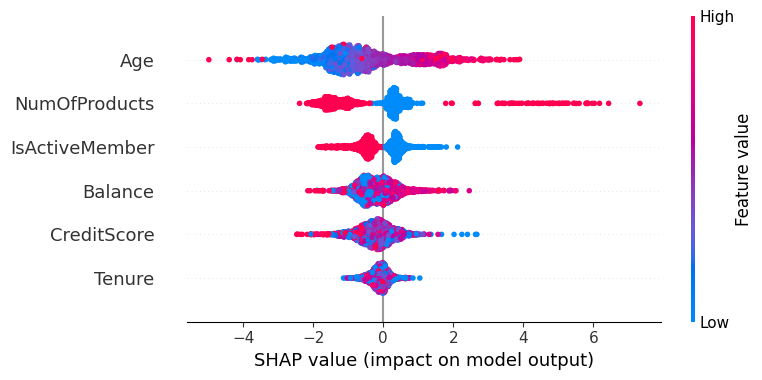

In [21]:
import shap

# Initialize the SHAP explainer with the XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Summary plot of SHAP values (impact of each feature on the prediction)
shap.summary_plot(shap_values, X_test)

The SHAP summary plot offers valuable insights into how different features influence the XGBoost model’s predictions for customer churn. The x-axis represents the SHAP value, which indicates the impact of each feature on the likelihood of churn. A positive SHAP value suggests that the feature increases the probability of a customer churning, while a negative value indicates the opposite. The features are listed on the y-axis in descending order of importance, with "Age," "IsActiveMember," and "NumOfProducts" being the most influential. From the plot, we observe that Age is the most significant factor, with older customers (shown in red) being more likely to churn, while younger customers (in blue) are less likely. IsActiveMember also plays a crucial role, where active members (red) have a lower churn risk compared to inactive ones (blue). Similarly, the number of products a customer holds impacts churn; customers with fewer products are more likely to leave the bank. Balance and CreditScore show more nuanced effects, where lower balances and credit scores slightly increase churn risk, though their impact is less significant compared to the top features.


# VIII. CUSTOMER SEGMENTATION

Given the insights gained the feature importance, SHAP analysis and both of the models XGBOOST and Logistic Regression, a targeted strategy for customer retention by segmenting customers based on the most influential features can be identified. Segmenting customers by the features Age, IsActiveMember, and NumOfProducts, allows us to group customers with similar characteristics and tailor retention strategies to address the specific needs and risks of each segment. 

Segmenting Customers:
Age-Based Segmentation: Since age is the most significant predictor of churn, we can create segments based on different age groups. For example, younger customers (under 30), middle-aged customers (30-50), and older customers (over 50) could be distinct segments. Younger customers might be more tech-savvy and responsive to digital engagement, while older customers might value more personalized and traditional forms of service. Retention strategies could involve offering digital tools and financial advice to younger customers, while providing personalized financial planning services to older customers.

Engagement Status (IsActiveMember): Another crucial segment is based on whether customers are active members. Active members, who frequently interact with the bank’s services, may not need as much attention, but it’s crucial to maintain their engagement. For inactive members, we should identify the reasons for their inactivity and re-engage them with personalized offers, loyalty programs, or incentives for using specific products. Inactive customers are at higher risk of churning, so proactive outreach and reactivation campaigns should be prioritized.

Product Holding (NumOfProducts): Customers can also be segmented based on the number of products they hold with the bank. Those with fewer products are more likely to churn, so cross-selling and upselling strategies should be targeted at this group. Educating these customers about the benefits of holding multiple products and offering bundled services at a discount could help increase their commitment to the bank. Conversely, customers with multiple products should be rewarded for their loyalty to ensure they remain engaged and satisfied.

Retention Strategy Development:
Personalized Engagement: For each customer segment, tailored communication and personalized offers are key. For instance, younger, tech-savvy customers might be more engaged through mobile apps and social media channels, while older customers might prefer direct mail or phone calls. Personalized financial advice, based on their product holding and financial behavior, can also add value and reduce churn likelihood.

Incentive Programs: Implement loyalty and incentive programs aimed at inactive members and those with fewer products. Offering rewards for increased product usage, or discounts on bundled services, can make staying with the bank more appealing than switching to a competitor. For inactive members, small incentives to return to regular banking activities, such as cash-back offers or waived fees, can help reactivate their engagement.

Proactive Support: For high-risk segments, such as older inactive customers or those with low product engagement, proactive support and check-ins can prevent churn. Regular contact through customer service, financial health checks, or invitations to special events can make these customers feel valued and less likely to leave.

# IX. DEPLOYMENT + REAL WORLD APPLICATION

Once the customer churn model has been developed and validated, the next crucial step is deployment into a live environment where it can be integrated with real-world banking operations. Deployment involves implementing the model in such a way that it continuously monitors and predicts customer behavior using live data, enabling timely interventions to prevent churn.

Integration with Live Data
For the churn prediction model to be effective in a real-world setting, it needs to be connected to live data streams from the bank’s customer database. This integration allows the model to process real-time customer transactions, interactions, and changes in account status. By feeding live data into the model, predictions can be made dynamically, reflecting the most current state of each customer. This real-time capability is essential for timely identification of at-risk customers, allowing the bank to intervene before a customer makes the decision to leave.

Real-Time Alerts and Automated Actions
In a fully deployed system, the model could be configured to trigger real-time alerts to customer service teams whenever a customer is identified as being at high risk of churn. These alerts can be accompanied by specific recommendations or actions, such as offering a personalized discount, scheduling a call with a relationship manager, or sending targeted communications. Furthermore, the system can automate certain actions, like sending out re-engagement emails or push notifications to customers who are flagged as at-risk, ensuring a swift and consistent response to potential churn.

Unified Platform for Customer Management
A key aspect of deployment is integrating the churn prediction model into a unified customer relationship management (CRM) platform. This platform would consolidate all relevant customer data, model predictions, and intervention tools in one place. Customer service representatives, marketing teams, and data analysts could all access the platform, using the same up-to-date information to guide their decisions. The platform could also feature dashboards that visualize churn risk across different segments, track the effectiveness of retention campaigns, and adjust strategies based on the latest model outputs and performance metrics.

Continuous Learning and Model Updates
In a live deployment, the model should be designed to continuously learn and adapt as new data becomes available. This could involve regular retraining of the model on recent customer data to ensure it stays accurate and relevant as customer behavior patterns evolve. Additionally, feedback loops can be established where the outcomes of retention interventions (e.g., whether a customer decided to stay after an offer was made) are fed back into the model to improve its predictions over time. 

# X. CONCLUSION

Deploying the customer churn model into a live banking environment offers significant opportunities for improving customer retention and enhancing overall customer experience. By leveraging live data, automated actions, and a unified platform, the bank can proactively manage churn in real-time, leading to more informed decisions, better customer interactions, and ultimately, higher customer loyalty and profitability. Continuous learning ensures that the model remains effective over time, adapting to changing customer behaviors and market conditions. This comprehensive approach to deployment ensures that the insights gained from the model translate into tangible business outcomes.